# 
Ther are two types of Ensemble Learning
## 1. Bagging
###     1. Random Forest
## 2. Boosting
###    1. Ada Boost
###    2. Gradient Boost
###    3. XG Boost
###    4. LAT Boost

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
data = pd.read_csv("Liver_Cancer.xls")
data.head()
data.tail()

,age,gender,bmi,alcohol_consumption,smoking_status,hepatitis_b,hepatitis_c,liver_function_score,alpha_fetoprotein_level,cirrhosis_history,family_history_cancer,physical_activity_level,diabetes,liver_cancer
4995,32,Male,20.1,Regular,Never,0,0,68.2,6.73,1,0,Moderate,0,0
4996,80,Male,16.9,Never,Never,1,0,80.2,44.66,0,0,Low,0,0
4997,51,Female,23.1,Occasional,Never,0,0,65.7,7.64,0,1,Low,0,0
4998,76,Female,26.4,Never,Never,0,1,26.4,6.15,0,0,Low,0,0
4999,33,Male,21.0,Regular,Never,0,0,58.1,4.78,1,0,Low,0,0


In [14]:
data["alcohol_consumption"].unique
data["physical_activity_level"].value_counts

<bound method IndexOpsMixin.value_counts of 0            Low
1       Moderate
2       Moderate
3            Low
4            Low
          ...   
4995    Moderate
4996         Low
4997         Low
4998         Low
4999         Low
Name: physical_activity_level, Length: 5000, dtype: object>

In [15]:
data["alcohol_consumption"] = data.alcohol_consumption.map({"Regular":1,"Occasional":2,"Never":0})
data["smoking_status"] = data.smoking_status.map({"Former":2,"Current":1,"Never":0})
data["physical_activity_level"] = data.physical_activity_level.map({"High":1,"Moderate":2,"Never":0, "Low":3})
data["gender"] = data.gender.map({"Female":0,"Male":1})
data.head()

,age,gender,bmi,alcohol_consumption,smoking_status,hepatitis_b,hepatitis_c,liver_function_score,alpha_fetoprotein_level,cirrhosis_history,family_history_cancer,physical_activity_level,diabetes,liver_cancer
0,68,0,18.1,1,2,0,0,51.9,16.44,0,0,3,0,0
1,81,0,19.9,2,0,0,0,41.6,8.09,0,0,2,1,0
2,58,0,25.5,0,0,0,0,76.0,0.64,0,0,2,0,0
3,44,1,16.0,0,2,0,0,50.3,19.09,0,0,3,1,0
4,72,1,21.0,2,2,0,0,39.5,4.95,1,0,3,1,1


In [16]:
data['physical_activity_level'].value_counts()

physical_activity_level
2    2027
3    1957
1    1016
Name: count, dtype: int64

In [17]:
data.isnull().sum()

age                        0
gender                     0
bmi                        0
alcohol_consumption        0
smoking_status             0
hepatitis_b                0
hepatitis_c                0
liver_function_score       0
alpha_fetoprotein_level    0
cirrhosis_history          0
family_history_cancer      0
physical_activity_level    0
diabetes                   0
liver_cancer               0
dtype: int64

In [18]:
data.info

<bound method DataFrame.info of       age  gender   bmi  alcohol_consumption  smoking_status  hepatitis_b  \
0      68       0  18.1                    1               2            0   
1      81       0  19.9                    2               0            0   
2      58       0  25.5                    0               0            0   
3      44       1  16.0                    0               2            0   
4      72       1  21.0                    2               2            0   
...   ...     ...   ...                  ...             ...          ...   
4995   32       1  20.1                    1               0            0   
4996   80       1  16.9                    0               0            1   
4997   51       0  23.1                    2               0            0   
4998   76       0  26.4                    0               0            0   
4999   33       1  21.0                    1               0            0   

      hepatitis_c  liver_function_score  al

In [19]:
data.describe()

,age,gender,bmi,alcohol_consumption,smoking_status,hepatitis_b,hepatitis_c,liver_function_score,alpha_fetoprotein_level,cirrhosis_history,family_history_cancer,physical_activity_level,diabetes,liver_cancer
count,5000.000000,5000.000000,5000.00000,5000.00000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,57.222800,0.498800,25.90464,0.99060,0.832200,0.15120,0.095800,65.203900,15.109424,0.301600,0.241400,2.188200,0.199200,0.217800
std,15.799224,0.500049,5.10520,0.89234,0.875783,0.35828,0.294346,14.875477,15.196809,0.458998,0.427975,0.747859,0.399439,0.412792
min,30.000000,0.000000,8.10000,0.00000,0.000000,0.00000,0.000000,5.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,44.000000,0.000000,22.50000,0.00000,0.000000,0.00000,0.000000,54.800000,4.357500,0.000000,0.000000,2.000000,0.000000,0.000000
50%,57.000000,0.000000,25.90000,1.00000,1.000000,0.00000,0.000000,65.200000,10.340000,0.000000,0.000000,2.000000,0.000000,0.000000
75%,71.000000,1.000000,29.30000,2.00000,2.000000,0.00000,0.000000,75.200000,21.010000,1.000000,0.000000,3.000000,0.000000,0.000000
max,84.000000,1.000000,43.70000,2.00000,2.000000,1.00000,1.000000,115.700000,136.800000,1.000000,1.000000,3.000000,1.000000,1.000000


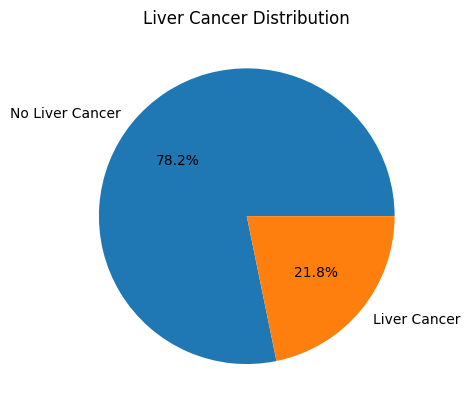

In [20]:
import matplotlib.pyplot as plt

counts = data['liver_cancer'].value_counts()

plt.pie(
    counts,
    labels=['No Liver Cancer', 'Liver Cancer'],
    autopct='%1.1f%%'
)

plt.title('Liver Cancer Distribution')
plt.show()

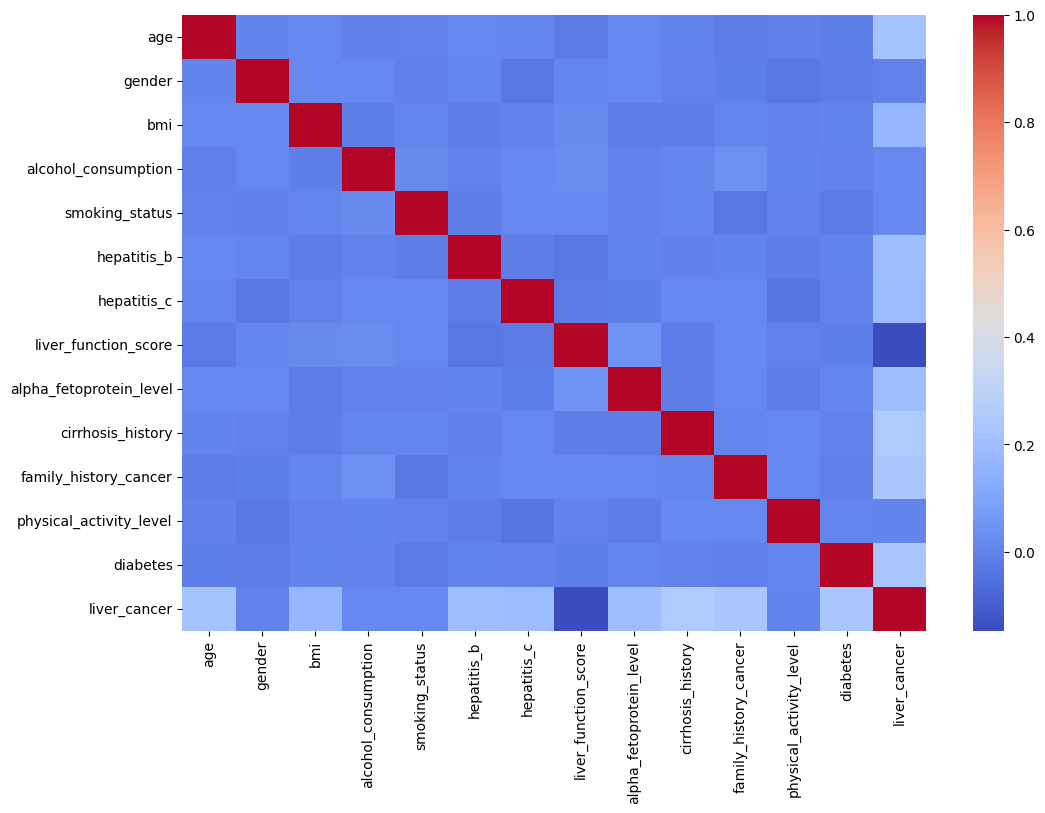

In [21]:
corr = data.corr()
corr['liver_cancer'].sort_values(ascending=False)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.show()

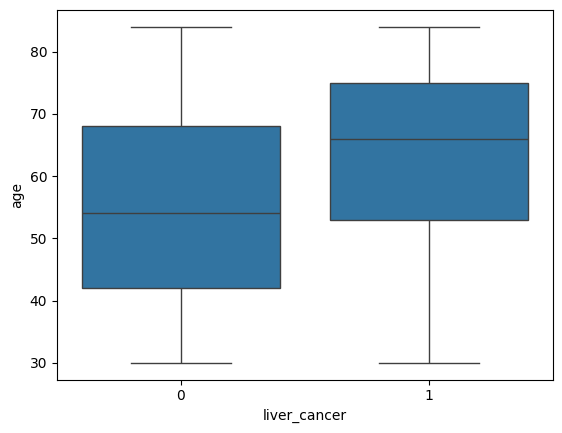

In [22]:
sns.boxplot(x='liver_cancer', y='age', data=data)
plt.show()

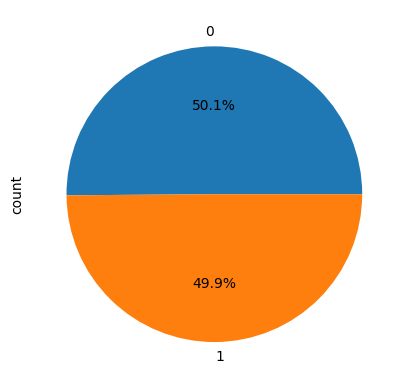

In [23]:
data['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()

In [24]:
print(data.columns.tolist())

['age', 'gender', 'bmi', 'alcohol_consumption', 'smoking_status', 'hepatitis_b', 'hepatitis_c', 'liver_function_score', 'alpha_fetoprotein_level', 'cirrhosis_history', 'family_history_cancer', 'physical_activity_level', 'diabetes', 'liver_cancer']


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = data.drop('liver_cancer', axis=1)
y = data['liver_cancer']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<Axes: >

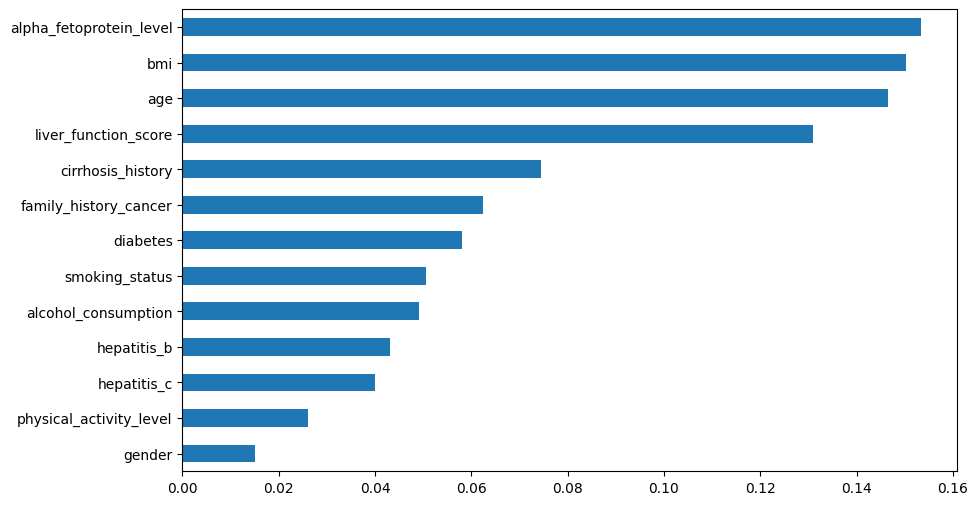

In [35]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

feature_importance.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

<Axes: xlabel='age', ylabel='Count'>

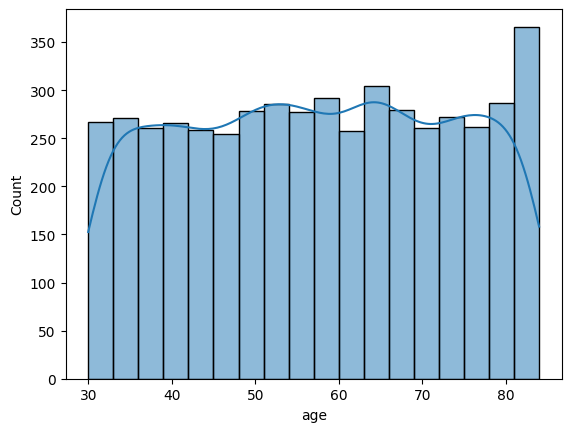

In [27]:
sns.histplot(data['age'], kde=True)

<Axes: xlabel='bmi', ylabel='Count'>

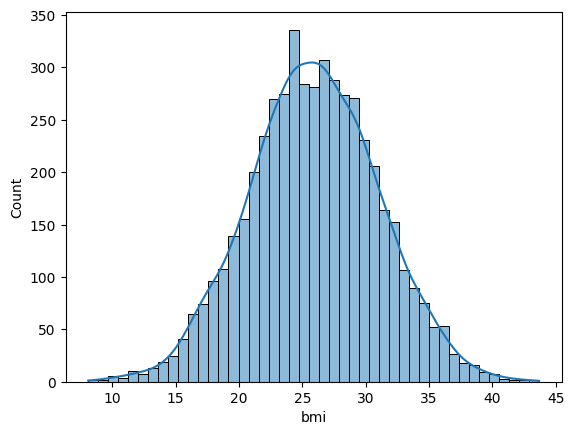

In [28]:
sns.histplot(data['bmi'], kde=True)

<Axes: xlabel='liver_cancer', ylabel='age'>

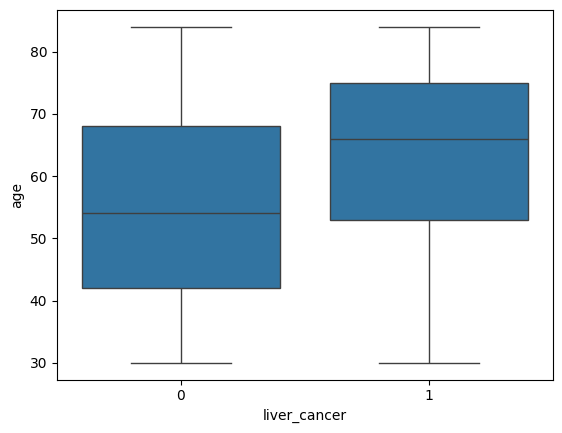

In [30]:
sns.boxplot(x='liver_cancer', y='age', data=data)

<Axes: xlabel='liver_cancer', ylabel='bmi'>

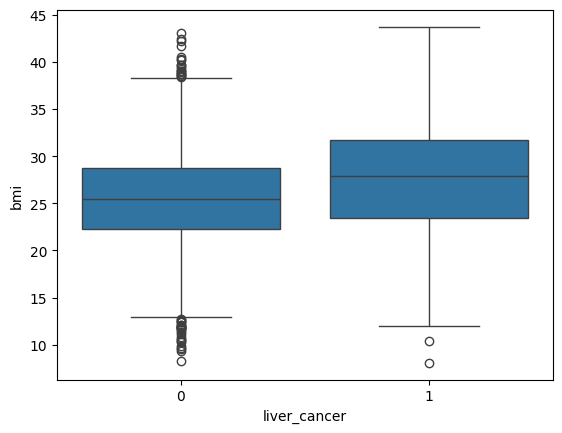

In [31]:
sns.boxplot(x='liver_cancer', y='bmi', data=data)

<Axes: xlabel='liver_cancer', ylabel='alcohol_consumption'>

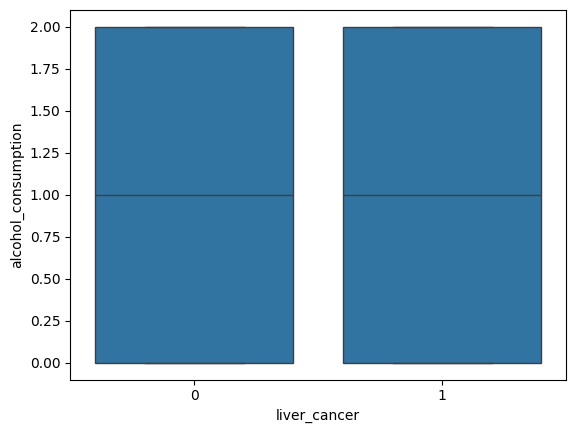

In [32]:
sns.boxplot(x='liver_cancer',
            y='alcohol_consumption',
            data=data)

<Axes: xlabel='hepatitis_b', ylabel='count'>

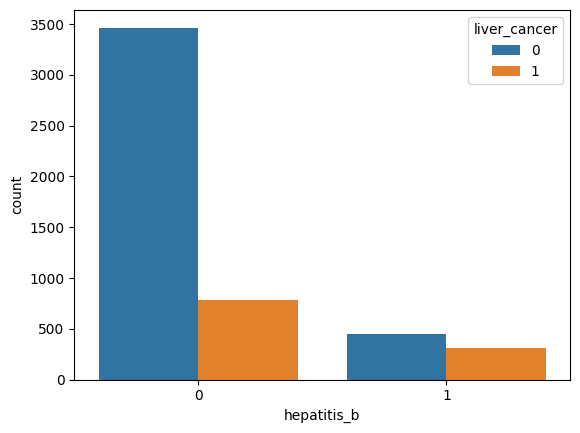

In [33]:
sns.countplot(
    x='hepatitis_b',
    hue='liver_cancer',
    data=data
)

<Axes: xlabel='hepatitis_c', ylabel='count'>

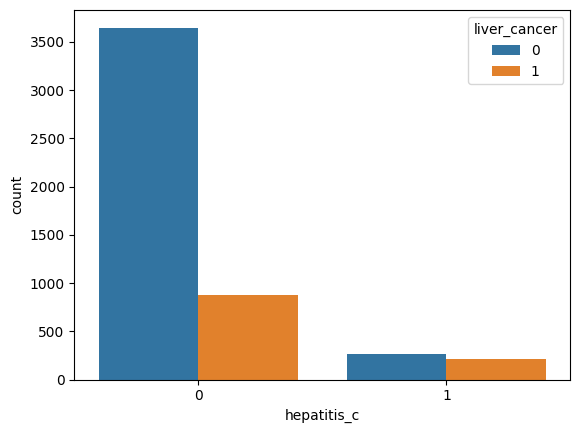

In [36]:
sns.countplot(
    x='hepatitis_c',
    hue='liver_cancer',
    data=data
)